In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(847063)

# Exercício 1

1. Gere uma amostra de tamanho $K$ de uma variável com distribuição binomial negativa com parâmetros $p$ $r$ utilizando os três métodos vistos em sala: via Bernoullis, via soma de geométricas, via recursão.
2. Compare com uma amostra gerada pelo numpy usando histogramas.
3. Compare o tempo dos três métodos como visto nos labs anteriores.


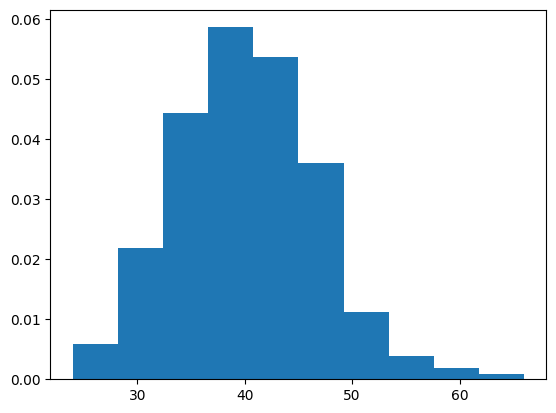

In [16]:
#Bernoulli
amostra = []
p = 0.5
r = 20
N = 1000
for i in range(N):
  n = 0
  x = 0
  while x < r:
    if(np.random.uniform() < p):
      n += 1
      x += 1
    else:
      n +=1
  amostra.append(n)

plt.hist(amostra, density=True)
plt.show()

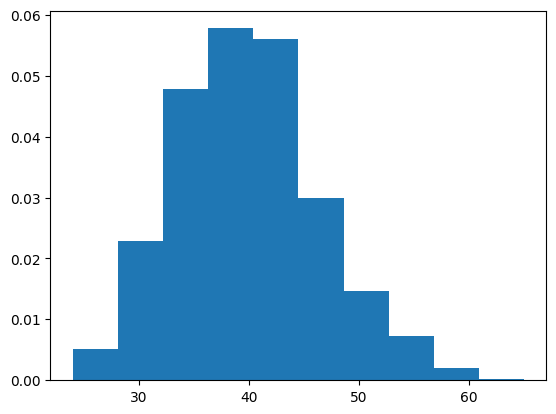

In [17]:
#Soma de Geométrica
def geom(p, r):
  n = []
  for i in range(r):
    j = np.ceil(np.log(1 - np.random.uniform())/np.log(1-p))
    n.append(j)
  return sum(n)

p = 0.5
r = 20
N = 1000

amostra = []
for i in range(N):
  amostra.append(geom(p, r))

plt.hist(amostra, density=True)
plt.show()

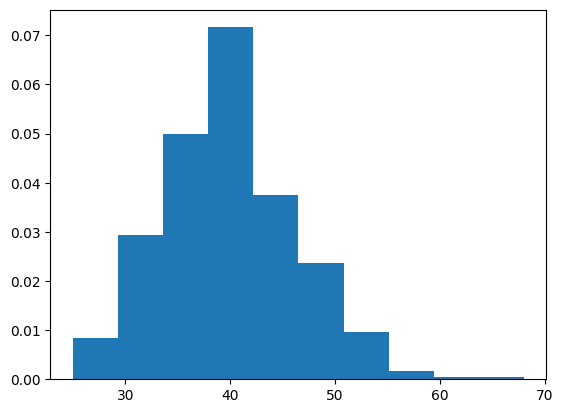

In [18]:
#Recursiva
p = 0.5
r = 20
N = 1000

amostra = []
for i in range(N):
  u = np.random.uniform()
  n = r
  pn = p**r
  F = pn
  while u > F:
    pn = pn * (n*(1-p)/(n-r+1))
    n += 1
    F += pn
  amostra.append(n)

plt.hist(amostra, density=True)
plt.show()

# Exercício 2

1.  Gere uma amostra de tamanho $K$ de uma variável aleatória com distribuição hipergeométrica com parâmetros $M,N,n$ utilizando o método de embaralhamento de Fisher–Yates.
2.  No método de Fisher-Yates, no passo (a), a gente amostra um ponto para troca entre $i$ e $N$. Pense em qual seria o problema caso a gente sempre amostrasse entre $1$ e $N$. Compare o resultado final usando essas duas versões e uma amostra gerada pelo numpy.

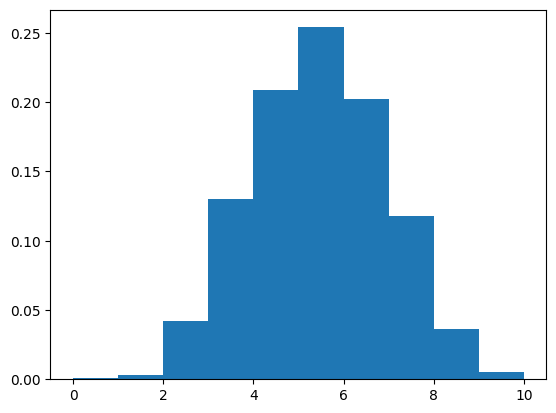

In [19]:
def hipergeometrica(N, M, n, k):
    amostra = []
    conjunto = N*[1] + M*[0]
    for i in range(k):
      elemn = conjunto.copy()
      for j in range(n):
        random = int(np.random.uniform()*(N+M-(j+1)))+(j+1)
        elemn[j], elemn[random] = elemn[random], elemn[j]
      amostra.append(np.sum(elemn[:n]))
    return amostra

dados = hipergeometrica(50, 50, 10, 1_000)
plt.hist(dados, density=True)
plt.show()

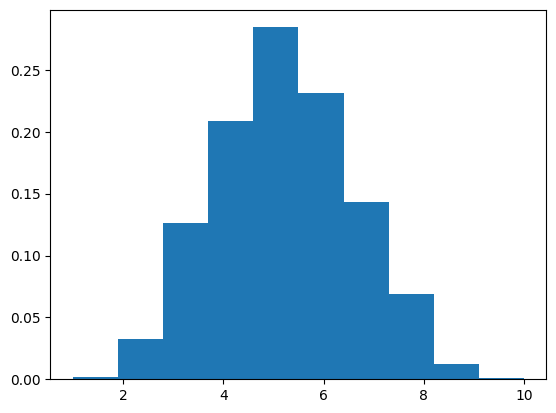

In [20]:
def hipergeometrica_errada(N, M, n, k):
    amostra = []
    conjunto = N*[1] + M*[0]
    for i in range(k):
      elemn = conjunto.copy()
      for j in range(n):
        random = int(np.random.uniform()*(N+M))
        elemn[j], elemn[random] = elemn[random], elemn[j]
      amostra.append(np.sum(elemn[:n]))
    return amostra

dados = hipergeometrica_errada(50, 50, 10, 1_000)
plt.hist(dados, density=True)
plt.show()

Com esse erro, indo de 1 a N a distribuição fica deslocada para a esquerda.

# Exercício 3

É intuitivo esperar que, quando o tamanho total da população $M+N$ cresce muito em relação ao tamanho da amostra $n$, o fato de a amostragem ser feita sem reposição passe a ter pouca importância, pois retirar um elemento altera muito pouco a composição da população restante. Nesse caso, cada retirada deve se comportar aproximadamente como um ensaio de Bernoulli independente, com probabilidade de sucesso

$$
p=\frac{N}{M+N}.
$$

Assim, esperamos que a distribuição hipergeométrica com parâmetros $M,N,n$ se aproxime de uma distribuição binomial com parâmetros $n$ e $p$.

Compare numericamente essas duas distribuições para valores crescentes de $M$ e $N$, mantendo aproximadamente constante a proporção

$$
\frac{N}{M+N}\to p,
$$

e mantendo $n$ fixo. Verifique, por meio de simulações, se a aproximação pela distribuição binomial melhora à medida que $M+N$ aumenta.


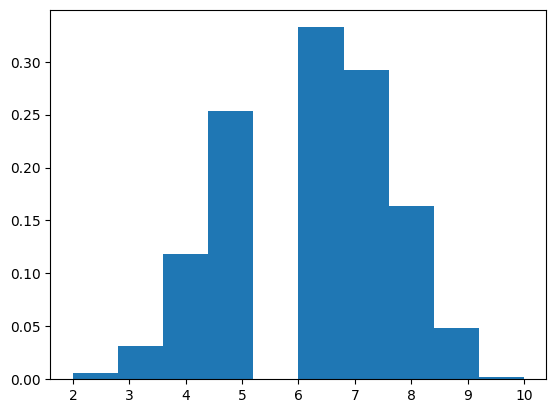

In [21]:
# N = 50; M = 30
dados = hipergeometrica(50, 30, 10, 1_000)
plt.hist(dados, density=True)
plt.show()

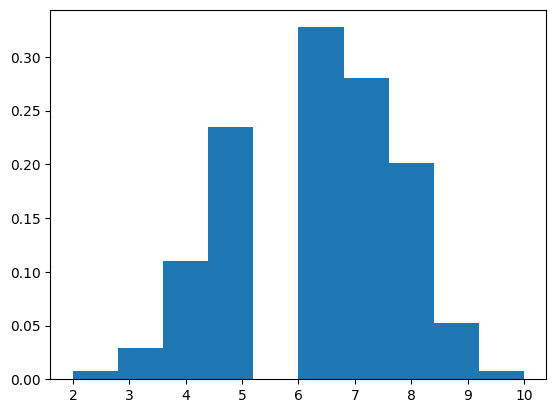

In [22]:
# N = 100; M = 60
dados = hipergeometrica(100, 60, 10, 1_000)
plt.hist(dados, density=True)
plt.show()

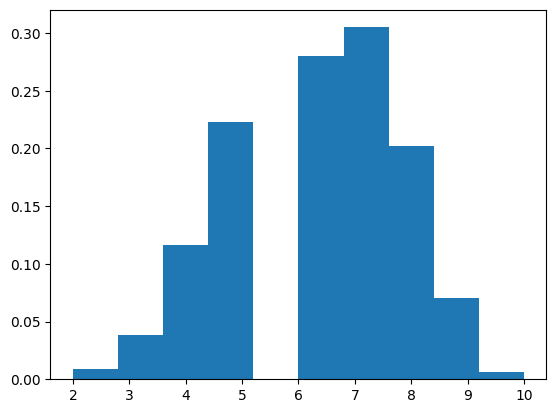

In [23]:
# N = 500; M = 300
dados = hipergeometrica(500, 300, 10, 1_000)
plt.hist(dados, density=True)
plt.show()

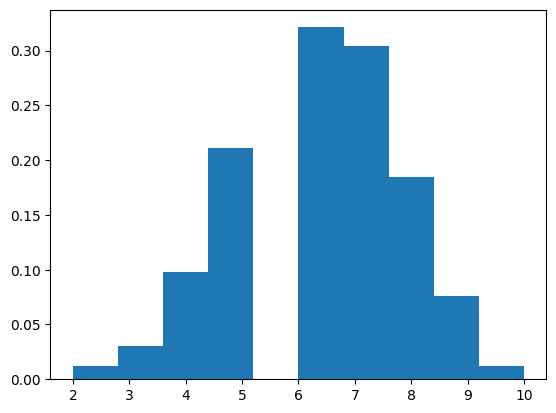

In [24]:
# N = 1000; M = 600
dados = hipergeometrica(1000, 600, 10, 1_000)
plt.hist(dados, density=True)
plt.show()

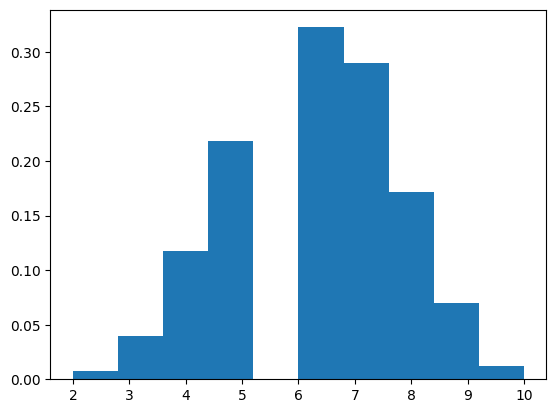

In [25]:
# N = 10_000; M = 6_000
dados = hipergeometrica(10_000, 6_000, 10, 1_000)
plt.hist(dados, density=True)
plt.show()

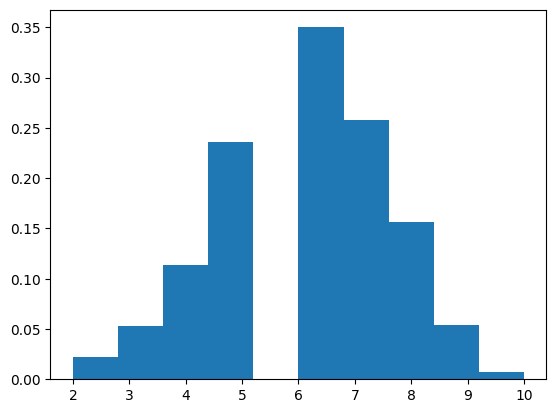

In [26]:
# Binomial n = 10; p = 0.6
dados = np.random.binomial(10, 0.6, 1000)
plt.hist(dados, density=True)
plt.show()